# Entrenamiento y selección de modelos para clasificación emocional

Este notebook implementa el pipeline **preprocesamiento -> vectorización TF-IDF -> entrenamiento de modelos (LR / SVM / NB) -> evaluación -> selección del modelo final**. La variable objetivo es `emotion`, y se comparan exclusivamente los modelos clásicos contemplados: **Logistic Regression**, **Linear SVM** y **Naive Bayes** .


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)


## 1. Carga del dataset


In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv('sentiment-emotion-labelled_Dell_tweets_enriched_v9.csv')
df.head()

DATA_PATH = 'sentiment-emotion-labelled_Dell_tweets_enriched_v9.csv'

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head(3)


Saving sentiment-emotion-labelled_Dell_tweets_enriched_v9.csv to sentiment-emotion-labelled_Dell_tweets_enriched_v9.csv
Shape: (24970, 70)


,Unnamed: 0,Datetime,Tweet Id,Text,Username,emotion,word_count,anger_count,joy_count,anticipation_count,disgust_count,sadness_count,fear_count,surprise_count,negation_count,negated_nrc_count,negated_anger_count,negated_joy_count,negated_anticipation_count,negated_disgust_count,negated_sadness_count,negated_fear_count,negated_surprise_count,intensifier_count,intensifier_max,intensified_nrc_count,anger_weighted,joy_weighted,anticipation_weighted,disgust_weighted,sadness_weighted,fear_weighted,surprise_weighted,exclamation_count,multi_exclamation,question_count,caps_word_count,caps_ratio,repeated_chars,punct_ratio,emoji_count,emoji_anger_count,emoji_joy_count,emoji_anticipation_count,emoji_disgust_count,emoji_sadness_count,emoji_fear_count,emoji_surprise_count,slang_count,slang_negative_count,slang_positive_count,slang_anger_count,slang_joy_count,slang_anticipation_count,slang_disgust_count,slang_sadness_count,slang_fear_count,slang_surprise_count,score_anger,score_joy,score_anticipation,score_disgust,score_sadness,score_fear,score_surprise,vader_compound,vader_positive,vader_negative,vader_neutral,vader_label
0,0,2022-09-30 23:29:15+00:00,1575991191170342912,@Logitech @apple @Google @Microsoft @Dell @Lenovo #WhatIf QWERTY were modified for programmers so things like bracke...,ManjuSreedaran,anticipation,34,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,1.3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1,0.0294,0,0.043,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.114282,0.0,0.0,0.6461,0.125,0.0,0.875,POSITIVO
1,1,2022-09-30 21:46:35+00:00,1575965354425131008,@MK_habit_addict @official_stier @MortalKombat @newzealand She's getting a new @Dell #laptop when the one she has on...,MiKeMcDnet,joy,23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0000,0,0.040,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0000,0.000,0.0,1.000,NEUTRO
2,2,2022-09-30 21:18:02+00:00,1575958171423752203,"As @CRN celebrates its 40th anniversary, Bob Faletra and @stevenjburke spoke with me about the milestones, companies...",jfollett,joy,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0000,0,0.024,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.5719,0.101,0.0,0.899,POSITIVO


In [ ]:
print('Columnas:')
print(df.columns.tolist())

print('Nulos por columna (solo > 0):')
nulls = df.isna().sum()
display(nulls[nulls > 0].sort_values(ascending=False).to_frame('nulls'))


Columnas:
['Unnamed: 0', 'Datetime', 'Tweet Id', 'Text', 'Username', 'emotion', 'word_count', 'anger_count', 'joy_count', 'anticipation_count', 'disgust_count', 'sadness_count', 'fear_count', 'surprise_count', 'negation_count', 'negated_nrc_count', 'negated_anger_count', 'negated_joy_count', 'negated_anticipation_count', 'negated_disgust_count', 'negated_sadness_count', 'negated_fear_count', 'negated_surprise_count', 'intensifier_count', 'intensifier_max', 'intensified_nrc_count', 'anger_weighted', 'joy_weighted', 'anticipation_weighted', 'disgust_weighted', 'sadness_weighted', 'fear_weighted', 'surprise_weighted', 'exclamation_count', 'multi_exclamation', 'question_count', 'caps_word_count', 'caps_ratio', 'repeated_chars', 'punct_ratio', 'emoji_count', 'emoji_anger_count', 'emoji_joy_count', 'emoji_anticipation_count', 'emoji_disgust_count', 'emoji_sadness_count', 'emoji_fear_count', 'emoji_surprise_count', 'slang_count', 'slang_negative_count', 'slang_positive_count', 'slang_anger_co

,nulls


## 2. Variable objetivo y análisis inicial

La variable objetivo es `sentiment`. Se revisa su distribución para confirmar si existe desbalance entre clases.


In [ ]:
target_col = 'emotion'
text_col = 'Text'

print(df[target_col].value_counts(dropna=False))
print('Porcentajes:')
print((df[target_col].value_counts(normalize=True, dropna=False) * 100).round(2))


emotion
anger           7520
joy             6326
anticipation    5171
disgust         3000
sadness         1328
optimism        1225
fear             366
surprise          34
Name: count, dtype: int64
Porcentajes:
emotion
anger           30.12
joy             25.33
anticipation    20.71
disgust         12.01
sadness          5.32
optimism         4.91
fear             1.47
surprise         0.14
Name: proportion, dtype: float64


## 3. Limpieza básica y selección de variables

Se excluyen variables que no aportan información relevante para el análisis `Tweet Id`, `Username` y `Datetime`

Se plantean dos escenarios de modelado:

1. **Texto solo**: `Text` vectorizado con TF-IDF.
2. **Texto + variables derivadas**: `Text` + variables numéricas auxiliares extraídas del tweet.


In [ ]:
exclude_cols = {
    'Unnamed: 0', 'Datetime', 'Tweet Id', 'Username',
    'sentiment', 'emotion'
}

# Variables potencialmente problemáticas por fuga de información.
# Por defecto las excluimos del entrenamiento.
leakage_like_cols = {
    'sentiment_score', 'emotion_score', 'vader_label'
}

# Puedes decidir aquí si quieres mantener o excluir VADER scores y score_*.
# Mantenerlos puede mejorar el rendimiento, pero conviene justificarlo bien.
keep_vader_scores = True
keep_emotion_scores = True

feature_df = df.copy()

if not keep_vader_scores:
    leakage_like_cols.update({'vader_compound', 'vader_positive', 'vader_negative', 'vader_neutral'})

if not keep_emotion_scores:
    leakage_like_cols.update({c for c in feature_df.columns if c.startswith('score_')})

numeric_features = [
    c for c in feature_df.columns
    if c not in exclude_cols
    and c not in leakage_like_cols
    and c != text_col
    and pd.api.types.is_numeric_dtype(feature_df[c])
]

print('Nº variables numéricas auxiliares:', len(numeric_features))
print(numeric_features[:30])


Nº variables numéricas auxiliares: 63
['word_count', 'anger_count', 'joy_count', 'anticipation_count', 'disgust_count', 'sadness_count', 'fear_count', 'surprise_count', 'negation_count', 'negated_nrc_count', 'negated_anger_count', 'negated_joy_count', 'negated_anticipation_count', 'negated_disgust_count', 'negated_sadness_count', 'negated_fear_count', 'negated_surprise_count', 'intensifier_count', 'intensifier_max', 'intensified_nrc_count', 'anger_weighted', 'joy_weighted', 'anticipation_weighted', 'disgust_weighted', 'sadness_weighted', 'fear_weighted', 'surprise_weighted', 'exclamation_count', 'multi_exclamation', 'question_count']


In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)
    text = re.sub(r'#(\w+)', r'  ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

feature_df[text_col] = feature_df[text_col].fillna('').apply(clean_text)
feature_df = feature_df[feature_df[target_col].notna()].copy()
feature_df[target_col] = feature_df[target_col].astype(str).str.strip().str.lower()

feature_df[[text_col, target_col]].head()


,Text,emotion
0,"user user user user user user  qwerty were modified for programmers so things like brackets, parens, quotes, operat...",anticipation
1,user user user user she's getting a new user  when the one she has one only 2-3 years old. (more than triple the pr...,joy
2,"as user celebrates its 40th anniversary, bob faletra and user spoke with me about the milestones, companies and pers...",joy
3,user your customer service is horrible especially agent syedfaisal who has made this experience of purchasing a new ...,anger
4,user user user user give the man what he paid for!,anger


## 4. División train/test

Se usa partición estratificada para conservar la proporción de clases en entrenamiento y prueba.


In [ ]:
X_text = feature_df[[text_col]].copy()
X_full = feature_df[[text_col] + numeric_features].copy()
y = feature_df[target_col].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_.tolist()

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y_encoded, test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE
)

X_train_full, X_test_full, _, _ = train_test_split(
    X_full, y_encoded, test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE
)

print('Train:', X_train_text.shape, 'Test:', X_test_text.shape)
print('Clases:', class_names)


Train: (19976, 1) Test: (4994, 1)
Clases: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'optimism', 'sadness', 'surprise']


## 5. Definición de pipelines

Se construyen pipelines homogéneos para comparar los modelos en igualdad de condiciones.


In [ ]:
text_transformer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

text_only_preprocessor = ColumnTransformer(
    transformers=[('text', text_transformer, text_col)],
    remainder='drop'
)

full_preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, text_col),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
            ('scaler', StandardScaler(with_mean=False))
        ]), numeric_features)
    ],
    remainder='drop'
)

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=None
    ),
    'Linear SVM': LinearSVC(
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'Multinomial NB': MultinomialNB()
}


## 6. Entrenamiento y evaluación comparativa

Se evalúan dos configuraciones:
- **Texto solo**
- **Texto + variables derivadas**

La métrica principal que se tendrá en cuenta para seleccionar el modelo será **F1 macro**, ya que equilibra el rendimiento entre clases y reduce el sesgo hacia la clase mayoritaria.


In [ ]:
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )

    results = {
        'model': name,
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
        'pipeline': pipeline,
        'y_pred': y_pred
    }

    if hasattr(pipeline, 'decision_function'):
        scores = pipeline.decision_function(X_test)
        y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))
        try:
            results['roc_auc_macro_ovr'] = roc_auc_score(y_test_bin, scores, average='macro', multi_class='ovr')
            results['pr_auc_macro'] = average_precision_score(y_test_bin, scores, average='macro')
        except Exception:
            results['roc_auc_macro_ovr'] = np.nan
            results['pr_auc_macro'] = np.nan
    elif hasattr(pipeline, 'predict_proba'):
        probs = pipeline.predict_proba(X_test)
        y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))
        try:
            results['roc_auc_macro_ovr'] = roc_auc_score(y_test_bin, probs, average='macro', multi_class='ovr')
            results['pr_auc_macro'] = average_precision_score(y_test_bin, probs, average='macro')
        except Exception:
            results['roc_auc_macro_ovr'] = np.nan
            results['pr_auc_macro'] = np.nan
    else:
        results['roc_auc_macro_ovr'] = np.nan
        results['pr_auc_macro'] = np.nan

    return results

results = []
trained_models = {}

from sklearn.preprocessing import MinMaxScaler

for model_name, estimator in models.items():
    pipe_text = Pipeline([
        ('preprocessor', text_only_preprocessor),
        ('model', estimator)
    ])
    res_text = evaluate_model(model_name + ' | texto', pipe_text, X_train_text, X_test_text, y_train, y_test)
    results.append(res_text)
    trained_models[res_text['model']] = res_text['pipeline']

for model_name, estimator in models.items():
    if isinstance(estimator, MultinomialNB):
        mnb_full_preprocessor = ColumnTransformer(
            transformers=[
                ('text', text_transformer, text_col),
                ('num', Pipeline([
                    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
                    ('scaler', MinMaxScaler())
                ]), numeric_features)
            ],
            remainder='drop'
        )
        pipe_full = Pipeline([
            ('preprocessor', mnb_full_preprocessor),
            ('model', estimator)
        ])
    else:
        pipe_full = Pipeline([
            ('preprocessor', full_preprocessor),
            ('model', estimator)
        ])

    res_full = evaluate_model(model_name + ' | texto+features', pipe_full, X_train_full, X_test_full, y_train, y_test)
    results.append(res_full)
    trained_models[res_full['model']] = res_full['pipeline']

results_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ['pipeline','y_pred']} for r in results])
results_df = results_df.sort_values(by=['f1_macro','accuracy'], ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro_ovr,pr_auc_macro
0,Linear SVM | texto+features,0.666600,0.507468,0.495033,0.500797,0.660921,0.666600,0.663558,0.872955,0.539239
1,Logistic Regression | texto+features,0.638166,0.477042,0.531988,0.493935,0.673914,0.638166,0.650309,0.834470,0.395588
2,Logistic Regression | texto,0.622747,0.485500,0.491509,0.482662,0.648721,0.622747,0.632533,0.848711,0.485181
3,Linear SVM | texto,0.638767,0.487980,0.471151,0.478571,0.632510,0.638767,0.635268,0.848729,0.513825
4,Multinomial NB | texto,0.577693,0.677818,0.297153,0.290935,0.647681,0.577693,0.505081,0.779428,0.441397
5,Multinomial NB | texto+features,0.594113,0.428148,0.289438,0.264595,0.582874,0.594113,0.509775,0.764642,0.439181


## 7. Selección del mejor modelo

Se selecciona automáticamente el modelo con mejor `f1_macro`.


In [ ]:
best_model_name = results_df.iloc[0]['model']
best_pipeline = trained_models[best_model_name]

print('Mejor modelo según F1 macro:', best_model_name)
display(results_df.head(10))

Mejor modelo según F1 macro: Linear SVM | texto+features


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro_ovr,pr_auc_macro
0,Linear SVM | texto+features,0.666600,0.507468,0.495033,0.500797,0.660921,0.666600,0.663558,0.872955,0.539239
1,Logistic Regression | texto+features,0.638166,0.477042,0.531988,0.493935,0.673914,0.638166,0.650309,0.834470,0.395588
2,Logistic Regression | texto,0.622747,0.485500,0.491509,0.482662,0.648721,0.622747,0.632533,0.848711,0.485181
3,Linear SVM | texto,0.638767,0.487980,0.471151,0.478571,0.632510,0.638767,0.635268,0.848729,0.513825
4,Multinomial NB | texto,0.577693,0.677818,0.297153,0.290935,0.647681,0.577693,0.505081,0.779428,0.441397
5,Multinomial NB | texto+features,0.594113,0.428148,0.289438,0.264595,0.582874,0.594113,0.509775,0.764642,0.439181


## 8. Informe de clasificación del mejor modelo


In [ ]:
if 'texto+features' in best_model_name:
    X_eval = X_test_full
else:
    X_eval = X_test_text

best_pred = best_pipeline.predict(X_eval)

print(classification_report(
    y_test,
    best_pred,
    target_names=class_names,
    zero_division=0
))


              precision    recall  f1-score   support

       anger       0.79      0.81      0.80      1504
anticipation       0.62      0.64      0.63      1034
     disgust       0.36      0.34      0.35       600
        fear       0.60      0.53      0.57        73
         joy       0.77      0.78      0.78      1265
    optimism       0.50      0.47      0.48       245
     sadness       0.42      0.38      0.40       266
    surprise       0.00      0.00      0.00         7

    accuracy                           0.67      4994
   macro avg       0.51      0.50      0.50      4994
weighted avg       0.66      0.67      0.66      4994



## 9. Matriz de confusión

La matriz de confusión ayuda a identificar en qué clases se equivoca más el modelo.


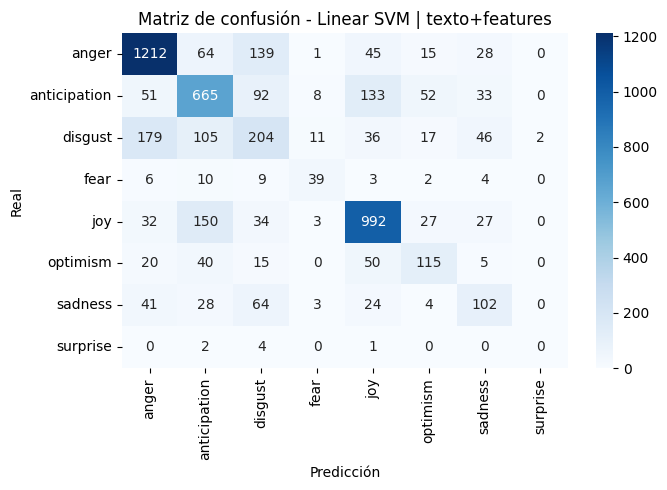

In [ ]:
cm = confusion_matrix(y_test, best_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(7,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión - {best_model_name}')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()


## 10. Curvas ROC y Precision-Recall

Para `LinearSVC` se utilizan los scores de decisión; para los modelos probabilísticos, `predict_proba`.


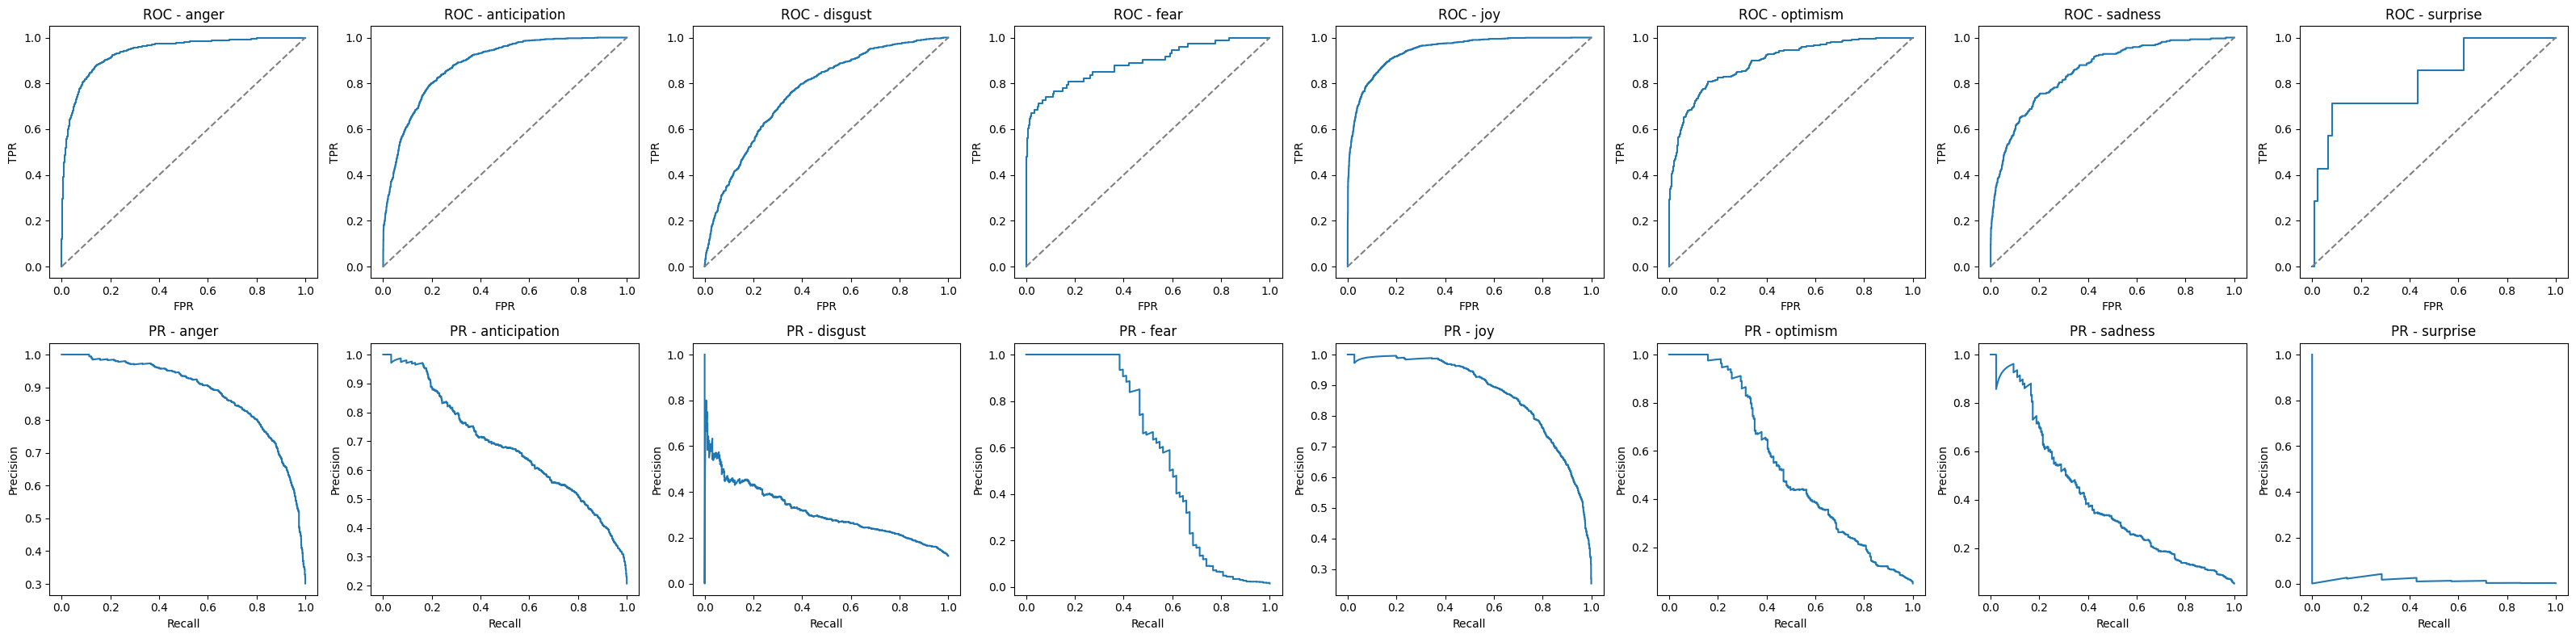

In [ ]:
from math import ceil

y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))

if hasattr(best_pipeline, 'decision_function'):
    y_score = best_pipeline.decision_function(X_eval)
elif hasattr(best_pipeline, 'predict_proba'):
    y_score = best_pipeline.predict_proba(X_eval)
else:
    y_score = None

if y_score is not None:
    n_classes = len(class_names)
    fig, axes = plt.subplots(2, n_classes, figsize=(4*n_classes, 8))

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])

        axes[0, i].plot(fpr, tpr)
        axes[0, i].plot([0,1],[0,1], linestyle='--', color='gray')
        axes[0, i].set_title(f'ROC - {class_name}')
        axes[0, i].set_xlabel('FPR')
        axes[0, i].set_ylabel('TPR')

        axes[1, i].plot(recall, precision)
        axes[1, i].set_title(f'PR - {class_name}')
        axes[1, i].set_xlabel('Recall')
        axes[1, i].set_ylabel('Precision')

    plt.tight_layout()
    plt.show()
else:
    print('El modelo no proporciona scores continuos para generar curvas ROC/PR.')


## 11. Explicabilidad global
Aquí se implementa **importancia por permutación** sobre el conjunto de test. Si el modelo resultante es una regresión logística, también se muestran los términos con mayor peso.


In [ ]:
sample_size = min(2000, len(X_eval))
X_eval_sample = X_eval.iloc[:sample_size].copy()
y_eval_sample = y_test[:sample_size]

perm = permutation_importance(
    best_pipeline,
    X_eval_sample,
    y_eval_sample,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='f1_macro'
)

# The feature names should correspond to the input features of permutation_importance
# which are the columns of X_eval_sample.
feature_names = X_eval_sample.columns.tolist()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

importance_df.head(20)

,feature,importance_mean,importance_std
0,Text,0.276415,0.003079
20,intensified_nrc_count,0.015030,0.001242
62,vader_negative,0.008346,0.002930
25,sadness_weighted,0.005688,0.001027
50,slang_sadness_count,0.004338,0.000719
51,slang_fear_count,0.004244,0.000583
37,emoji_joy_count,0.003671,0.000821
21,anger_weighted,0.003663,0.001240
30,question_count,0.003325,0.001417
60,vader_compound,0.003296,0.002460


In [ ]:
top_imp = importance_df.head(20).sort_values('importance_mean')
plt.figure(figsize=(10,8))
plt.barh(top_imp['feature'], top_imp['importance_mean'])
plt.title(f'Importancia global por permutación - {best_model_name}')
plt.xlabel('Descenso medio en F1 macro')
plt.tight_layout()
plt.show()

In [ ]:
if 'Logistic Regression' in best_model_name:
    model = best_pipeline.named_steps['model']
    preprocessor = best_pipeline.named_steps['preprocessor']
    feature_names = preprocessor.get_feature_names_out()

    coef_df_list = []
    for idx, cls in enumerate(class_names):
        class_coef = pd.DataFrame({
            'feature': feature_names,
            'coef': model.coef_[idx],
            'class': cls
        })
        coef_df_list.append(class_coef)

    coef_df = pd.concat(coef_df_list, ignore_index=True)

    for cls in class_names:
        print(f'\nTop términos positivos para la clase: {cls}')
        display(coef_df[coef_df['class'] == cls].sort_values('coef', ascending=False).head(10))
else:
    print('El modelo final no es Logistic Regression; se mantiene la explicabilidad global por permutación.')

El modelo final no es Logistic Regression; se mantiene la explicabilidad global por permutación.


## 12. Explicabilidad local: análisis de predicciones individuales

Se muestran algunos ejemplos correctamente clasificados y algunos errores para su documentación.

In [ ]:
eval_df = feature_df.loc[X_eval.index if hasattr(X_eval, 'index') else X_test_text.index].copy() if isinstance(X_eval, pd.DataFrame) else feature_df.iloc[:len(best_pred)].copy()

# Reconstruimos correctamente el dataframe de evaluación a partir del split correspondiente
if 'texto+features' in best_model_name:
    eval_index = X_test_full.index
else:
    eval_index = X_test_text.index

local_df = feature_df.loc[eval_index, [text_col, target_col]].copy()
local_df['y_true'] = label_encoder.inverse_transform(y_test)
local_df['y_pred'] = label_encoder.inverse_transform(best_pred)
local_df['correct'] = local_df['y_true'] == local_df['y_pred']

print('Ejemplos correctos:')
display(local_df[local_df['correct']].head(5))

print('Errores de clasificación:')
display(local_df[~local_df['correct']].head(10))


Ejemplos correctos:


,Text,emotion,y_true,y_pred,correct
19852,user user user user user user user user user user user user user user user user speak out against the discrimination...,anger,anger,anger,True
21194,user user user user user user user then you use the following link to go from umbrel -&gt; citadel -&gt; url but may...,anticipation,anticipation,anticipation,True
8460,user user user user congratulations,joy,joy,joy,True
5415,user service center. there i got to know that it will take one month to repair my laptop. i again went back to user ...,anger,anger,anger,True
2387,". user denied my refund request, as they have with many other users. they won't issue a recall. they don't have a fi...",anger,anger,anger,True


Errores de clasificación:


,Text,emotion,y_true,y_pred,correct
6870,"its been a long day user ,but i wouldn't have it any other way. great to meet all the new students coming in this ye...",joy,joy,anticipation,False
11139,where are the biggest texans and the biggest texas corporations when it comes to stepping up against gun violence? u...,disgust,disgust,anger,False
22651,part 1 - user user so let’s go about this the calm way first. my nephew 11 years old bought a gaming monitor with hi...,disgust,disgust,anger,False
21733,the amd powered user blade 14 and user g5 take home high-marks for top 2022 gaming systems. user has the details on ...,anticipation,anticipation,joy,False
11874,"user were already *numerous* reasons to be skeptical about tesla &amp; musk, including use of ""child labour and appa...",disgust,disgust,sadness,False
9555,user user user user user user user user user looks slick!,joy,joy,anticipation,False
24547,"i’m here to show my support for democracy, unlike user ! url",optimism,optimism,anger,False
20074,here’s my  lab. what’s yours look like? i have an old macbook being used on the big monitor and the other machine i...,anticipation,anticipation,joy,False
11635,"msps - want to leverage social media to help you get more clients? in this free training with eric d townsend, you'l...",anticipation,anticipation,optimism,False
1317,user user drew what are you doing on saturday,disgust,disgust,anticipation,False
